# Relevance filter report

Summarizes **filter_relevance** results per curriculum subtopic and explores how **embedding similarity** relates to **LLM confidence**.

**Prerequisites:** Postgres running, `alembic upgrade head`, and `filter_relevance` completed (`python scripts/run_pipeline.py --pipeline-version 2 --steps filter_relevance`).

For charts: `uv sync --extra dev` (installs matplotlib). Restart the kernel after syncing.

## Setup

In [16]:
import json
import sys
from pathlib import Path

import numpy as np
from IPython.display import HTML, display
from sqlalchemy import text as sa_text

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data" / "docs" / "extracted_source_content" / "biology"
CURRICULUM_PATH = DATA_DIR / "curriculum_validated.json"

from ibrary.config import POSTGRES_SCHEMA
from ibrary.curriculum.schemas import ValidatedCurriculum
from ibrary.db import get_session

TBL = f"{POSTGRES_SCHEMA}.chunk_relevance"
print("Project root:", PROJECT_ROOT)
print("Curriculum:", CURRICULUM_PATH, "exists:", CURRICULUM_PATH.exists())

Project root: c:\Users\Motunrayo Ibiyo\Documents\IBrary
Curriculum: c:\Users\Motunrayo Ibiyo\Documents\IBrary\data\docs\extracted_source_content\biology\curriculum_validated.json exists: True


## Load data

In [17]:
curriculum = ValidatedCurriculum.model_validate_json(CURRICULUM_PATH.read_text(encoding="utf-8"))
unit_by_id = {u.curriculum_unit_id: u for u in curriculum.units}

session = get_session()
try:
    rows = session.execute(
        sa_text(
            f"""
            SELECT curriculum_unit_id, chunk_id, relevant,
                   embedding_score, confidence
            FROM {TBL}
            ORDER BY curriculum_unit_id, embedding_score DESC NULLS LAST
            """
        )
    ).fetchall()
finally:
    session.close()

if not rows:
    raise RuntimeError(
        "No chunk_relevance rows found. Run filter_relevance first."
    )

print(f"Scored chunk×unit pairs: {len(rows)}")
print(f"Curriculum subtopics: {len(curriculum.units)}")

Scored chunk×unit pairs: 778
Curriculum subtopics: 88


## Relevant content per subtopic

In [18]:
from collections import defaultdict

stats: dict[str, dict] = defaultdict(lambda: {"scored": 0, "relevant": 0})
for r in rows:
    uid = r.curriculum_unit_id
    stats[uid]["scored"] += 1
    if r.relevant:
        stats[uid]["relevant"] += 1

report_rows = []
for unit in sorted(
    curriculum.units,
    key=lambda u: (u.theme_number, u.topic_number, u.content_index),
):
    s = stats.get(unit.curriculum_unit_id, {"scored": 0, "relevant": 0})
    report_rows.append(
        {
            "theme": unit.theme,
            "topic": unit.topic,
            "subtopic": unit.content_text,
            "unit_id": unit.curriculum_unit_id,
            "chunks_scored": s["scored"],
            "relevant_chunks": s["relevant"],
        }
    )

total_relevant = sum(r["relevant_chunks"] for r in report_rows)
subtopics_with_relevant = sum(1 for r in report_rows if r["relevant_chunks"] > 0)
print(f"Total relevant chunks (across all subtopics): {total_relevant}")
print(f"Subtopics with ≥1 relevant chunk: {subtopics_with_relevant} / {len(report_rows)}")

html = [
    "<table><thead><tr>",
    "<th>Theme</th><th>Topic</th><th>Subtopic</th>",
    "<th>Relevant</th><th>Scored</th><th>Unit ID</th>",
    "</tr></thead><tbody>",
]
for r in report_rows:
    subtopic = r["subtopic"][:120] + ("…" if len(r["subtopic"]) > 120 else "")
    html.append(
        f"<tr><td>{r['theme']}</td><td>{r['topic']}</td>"
        f"<td>{subtopic}</td>"
        f"<td style='text-align:right'><b>{r['relevant_chunks']}</b></td>"
        f"<td style='text-align:right'>{r['chunks_scored']}</td>"
        f"<td><code>{r['unit_id']}</code></td></tr>"
    )
html.append("</tbody></table>")
display(HTML("".join(html)))

Total relevant chunks (across all subtopics): 306
Subtopics with ≥1 relevant chunk: 74 / 88


Theme,Topic,Subtopic,Relevant,Scored,Unit ID
Organisation Of Life,Recognizing Living Things,Characteristics of living things,1,2,bio_sss1_theme1_topic1_content0
Organisation Of Life,Recognizing Living Things,Differences between plants and animals,1,2,bio_sss1_theme1_topic1_content1
Organisation Of Life,Recognizing Living Things,"Levels of organization of life: (a) Cell (Euglena, paramecium), Tissue (hydra), Organ (Onion bulb, the heart of a cow), …",1,2,bio_sss1_theme1_topic1_content2
Organisation Of Life,Recognizing Living Things,Complexity of organization in higher organisms: advantages and disadvantages,1,2,bio_sss1_theme1_topic1_content3
Organisation Of Life,Classification of Living Things,"Kingdom Monera (Prokaryote): single-celled, motile or non-motile organisms. No definite nucleus. Bacteria and blue-green…",3,10,bio_sss1_theme1_topic2_content0
Organisation Of Life,Classification of Living Things,"Kingdom Protista (Eukaryote): single-celled, motile or non-motile organisms. Complex cell structure with definite nucleu…",0,10,bio_sss1_theme1_topic2_content1
Organisation Of Life,Classification of Living Things,"Kingdom Fungi (Eukaryote): mainly non-motile organisms, composed of hyphae containing nuclei e.g. moulds, mushrooms and …",0,10,bio_sss1_theme1_topic2_content2
Organisation Of Life,Classification of Living Things,"Kingdom Plantae (Eukaryote): many-celled, non-motile organisms which contain chlorophyll that enable them to photosynthe…",0,10,bio_sss1_theme1_topic2_content3
Organisation Of Life,Classification of Living Things,"Kingdom Animalia (Eukaryote): many-celled, motile organisms that feed on other organisms. Members include corals, worms,…",1,10,bio_sss1_theme1_topic2_content4
Organisation Of Life,The Cell,Cell as a living unit of an organism,4,10,bio_sss1_theme1_topic3_content0


## Embedding score vs LLM confidence

Embedding score = pgvector cosine similarity from alignment (0–1).  
LLM confidence = relevance agent score (0–10).

In [19]:
pairs = [
    (float(r.embedding_score), float(r.confidence), bool(r.relevant))
    for r in rows
    if r.embedding_score is not None and r.confidence is not None
]

emb = np.array([p[0] for p in pairs])
conf = np.array([p[1] for p in pairs])
rel = np.array([p[2] for p in pairs])

def pearson(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def rankdata(a: np.ndarray) -> np.ndarray:
    """Average ranks for Spearman (ties get mean rank)."""
    order = a.argsort()
    ranks = np.empty(len(a), dtype=float)
    ranks[order] = np.arange(1, len(a) + 1)
    sorted_a = a[order]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sorted_a[j + 1] == sorted_a[i]:
            j += 1
        avg = (i + j + 2) / 2.0
        ranks[order[i : j + 1]] = avg
        i = j + 1
    return ranks


def spearman(x: np.ndarray, y: np.ndarray) -> float:
    return pearson(rankdata(x), rankdata(y))


print(f"Pairs with both scores: {len(pairs)} / {len(rows)}")
print(f"Pearson r (embedding vs confidence):  {pearson(emb, conf):.3f}")
print(f"Spearman ρ (embedding vs confidence): {spearman(emb, conf):.3f}")

for label, mask in [("all", np.ones(len(pairs), dtype=bool)), ("relevant=true", rel), ("relevant=false", ~rel)]:
    n = int(mask.sum())
    if n < 2:
        print(f"  [{label}] n={n} — too few for correlation")
        continue
    print(
        f"  [{label}] n={n}: Pearson={pearson(emb[mask], conf[mask]):.3f}, "
        f"Spearman={spearman(emb[mask], conf[mask]):.3f}"
    )

print("\nSummary stats:")
for name, arr in [("embedding_score", emb), ("confidence", conf)]:
    print(
        f"  {name}: mean={arr.mean():.3f}, std={arr.std():.3f}, "
        f"min={arr.min():.3f}, max={arr.max():.3f}"
    )

Pairs with both scores: 778 / 778
Pearson r (embedding vs confidence):  0.379
Spearman ρ (embedding vs confidence): 0.345
  [all] n=778: Pearson=0.379, Spearman=0.345
  [relevant=true] n=306: Pearson=0.215, Spearman=0.201
  [relevant=false] n=472: Pearson=-0.229, Spearman=-0.173

Summary stats:
  embedding_score: mean=0.499, std=0.073, min=0.247, max=0.691
  confidence: mean=3.190, std=3.874, min=0.000, max=9.000


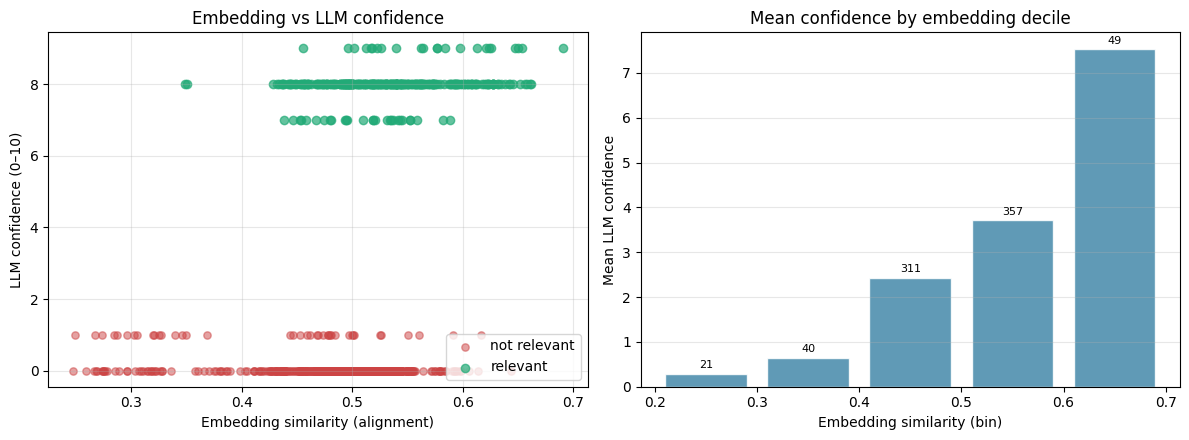

In [20]:
try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "matplotlib is required for plots. From the repo root run:\n"
        "  uv sync --extra dev\n"
        "Then restart the notebook kernel."
    ) from e

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.scatter(emb[~rel], conf[~rel], alpha=0.5, s=28, label="not relevant", c="#c44")
ax.scatter(emb[rel], conf[rel], alpha=0.7, s=36, label="relevant", c="#2a7")
ax.set_xlabel("Embedding similarity (alignment)")
ax.set_ylabel("LLM confidence (0–10)")
ax.set_title("Embedding vs LLM confidence")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
bins = np.linspace(0, 1, 11)
centers = 0.5 * (bins[:-1] + bins[1:])
means, counts = [], []
for i in range(len(bins) - 1):
    m = (emb >= bins[i]) & (emb < bins[i + 1]) if i < len(bins) - 2 else (emb >= bins[i]) & (emb <= bins[i + 1])
    if m.any():
        means.append(conf[m].mean())
        counts.append(int(m.sum()))
    else:
        means.append(np.nan)
        counts.append(0)
ax2.bar(centers, means, width=0.08, color="#48a", alpha=0.85, edgecolor="white")
ax2.set_xlabel("Embedding similarity (bin)")
ax2.set_ylabel("Mean LLM confidence")
ax2.set_title("Mean confidence by embedding decile")
ax2.grid(True, axis="y", alpha=0.3)
for x, y, n in zip(centers, means, counts):
    if n and not np.isnan(y):
        ax2.annotate(str(n), (x, y), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8)

plt.tight_layout()
plt.show()